In [1]:
import pandas as pd
import numpy as np
from src.model_pipeline import ModelPipeline

In [2]:
# df_final = pd.read_parquet("data/feature_engineering/credit/v3/df_credit_final.parquet")
df_final = pd.read_parquet("data/feature_engineering/credit/v3/df_credit_final_20250620.parquet")
df_final = df_final.set_index("Transaction Serial No", drop=True)

# Final Drop Columns

In [14]:
all_feats = [
    'time_diff',
    'POSMode_FE',
    'MCC Category_FE',
    'TransactionType_FE',
    'TxnCount_to_MCC_cat_L90D',
    'Transaction Amount',
    'TxnCount_to_cardAcceptor_cat_L90D',
    'Sum_Amt_to_cardAcceptor_country_L90D',
    'Max_Amt_to_MCC_L90D',
    'Max_Amt_to_cardAcceptor_country_L90D',
    'Sum_Amt_to_MCC_L90D',
    'CntUnique_CardNo_by_cardAcceptor_country_L1H',
    'Cat Card Acceptor Name_FE',
    'Avg_Amt_to_cardAcceptor_country_L90D',
    'CntUnique_CardNo_by_cardAcceptor_cat_L14D',
    'Avg_Amt_to_MCC_L90D',
    'TxnCount_to_countryCode_L90D',
    'TotalTrxAmount30Mi',
    'TotalTrxAmount15Mi',
    'CntUnique_CardNo_by_cardAcceptor_country_L15M',
    'CntUnique_CardNo_by_cardAcceptor_cat_L30D',
    'TotalTrxAmountL5min',
    'TotalTrxAmount10Mi',
    'Sum_Amt_to_cardAcceptor_cat_L90D',
    'CntUnique_CardNo_by_cardAcceptor_cat_L7D',
    'Max_Amt_to_MCC_cat_L90D',
    'TxnCount_to_countryCode_L30D',
    'Sum_Amt_to_MCC_cat_L90D',
    'Sum_Amt_to_cardAcceptor_country_L30D',
    'Max_Amt_to_cardAcceptor_cat_L90D',
    'CntUnique_CardNo_by_cardAcceptor_cat_L1D',
    'Avg_Amt_to_MCC_cat_L90D',
    'TxnCount_L90D',
    'Avg_Amt_to_cardAcceptor_cat_L90D',
    'TxnCount_to_MCC_catcode_L90D',
    'Max_Amt_L15M',
    'Avg_Amt_to_cardAcceptor_country_L30D',
    'PINEntryCapability_FE',
    'Max_Amt_to_cardAcceptor_country_L30D',
    'TxnCount_L30D',
    'Max_Amt_to_MCC_L30D',
    'TotalTrxAmountL1D',
    'Max_Amt_to_cardAcceptor_country_L14D',
    'Sum_Amt_to_MCC_cat_L30D',
    'Currency_FE',
    'Max_Amt_L1H',
    'Sum_Amt_to_cardAcceptor_country_L15M',
    'TxnCount_to_MCC_catcode_L30D',
    'Max_Amt_to_cardAcceptor_cat_L30D',
    'Sum_Amt_to_MCC_L30D',
    'Max_Amt_to_cardAcceptor_country_L1H',
    'Max_Amt_to_cardAcceptor_country_L15M',
    'Max_Amt_to_MCC_cat_L30D',
    'CntUnique_CardNo_by_MCC_L1D',
    'Avg_Amt_to_MCC_cat_L30D',
    'Avg_Amt_to_MCC_L30D',
    'Sum_Amt_to_cardAcceptor_country_L1H',
    'Sum_Amt_to_cardAcceptor_country_L14D',
    'Sum_Amt_to_countryCode_L15M',
    'Avg_Amt_to_cardAcceptor_country_L14D',
    'Avg_Amt_to_cardAcceptor_country_L7D',
    'Avg_Amt_to_cardAcceptor_cat_L30D',
    'Sum_Amt_to_cardAcceptor_cat_L30D',
    'Sum_Amt_to_MCC_cat_L1H',
    'Max_Amt_to_countryCode_L1H',
    'Max_Amt_to_MCC_cat_L15M',
    'Country Code_FE',
    'CardProduct_FE',
    'Avg_Amt_to_cardAcceptor_country_L15M',
    'Max_Amt_to_cardAcceptor_country_L7D',
    'Max_Amt_to_countryCode_L15M',
    'Sum_Amt_to_MCC_cat_L15M',
    'Avg_Amt_L15M',
    'Max_Amt_to_MCC_L14D',
    'Max_Amt_to_MCC_cat_L1H',
    'VCardDataInputCapability_FE',
    'Sum_Amt_to_cardAcceptor_country_L1D',
    'Sum_Amt_to_MCC_L14D',
    'Max_Amt_L1D',
    'Avg_Amt_to_cardAcceptor_cat_L14D',
    'Avg_Amt_to_MCC_cat_L14D',
    'Sum_Amt_to_cardAcceptor_cat_L15M',
    'Max_Amt_to_MCC_cat_L14D',
    'Max_Amt_to_cardAcceptor_cat_L14D',
    'Max_Amt_to_cardAcceptor_country_L1D',
    'Max_Amt_to_MCC_cat_L7D',
    'Max_Amt_to_cardAcceptor_cat_L15M',
    'Avg_Amt_to_MCC_L14D',
    'SourceChannel_FE',
    'Sum_Amt_to_MCC_cat_L14D',
    'Avg_Amt_to_cardAcceptor_cat_L7D',
    'Max_Amt_to_cardAcceptor_cat_L7D',
    'Max_Amt_to_countryCode_L1D',
    'Max_Amt_to_MCC_L7D',
    'Sum_Amt_to_cardAcceptor_cat_L14D',
    'Sum_Amt_to_MCC_cat_L7D',
    'Sum_Amt_to_MCC_L7D',
    'Max_Amt_to_cardAcceptor_cat_L1D',
    'Sum_Amt_to_cardAcceptor_cat_L7D',
    'Max_Amt_to_MCC_L1H',
    'Max_Amt_to_MCC_cat_L1D',
    'Avg_Amt_to_MCC_cat_L7D',
    'CustomerSex_FE',
    'Avg_Amt_to_MCC_L7D',
    'Avg_Amt_to_MCC_cat_L15M',
    'Sum_Amt_to_MCC_cat_L1D',
    'Currency Code_FE',
    'Max_Amt_to_MCC_L15M',
    'Max_Amt_to_MCC_L1D',
    'Sum_Amt_to_MCC_L15M',
    'CardStatus_FE',
    'Sum_Amt_to_MCC_L1H',
    'Sum_Amt_to_cardAcceptor_cat_L1H',
    'Max_Amt_to_cardAcceptor_cat_L1H',
    'AccountStatus_FE',
    'CustomerNationality_FE'
]

In [3]:
derived_cols = [
    'Avg_Amt_L15M',
    'Avg_Amt_to_MCC_L14D',
    'Avg_Amt_to_MCC_L30D',
    'Avg_Amt_to_MCC_L7D',
    'Avg_Amt_to_MCC_L90D',
    'CntUnique_CardNo_by_MCC_L1D',
    'Max_Amt_L15M',
    'Max_Amt_L1D',
    'Max_Amt_L1H',
    'Max_Amt_to_MCC_L14D',
    'Max_Amt_to_MCC_L15M',
    'Max_Amt_to_MCC_L1D',
    'Max_Amt_to_MCC_L1H',
    'Max_Amt_to_MCC_L30D',
    'Max_Amt_to_MCC_L7D',
    'Max_Amt_to_MCC_L90D',
    'Max_Amt_to_countryCode_L15M',
    'Max_Amt_to_countryCode_L1D',
    'Max_Amt_to_countryCode_L1H',
    'Sum_Amt_to_MCC_L14D',
    'Sum_Amt_to_MCC_L15M',
    'Sum_Amt_to_MCC_L1H',
    'Sum_Amt_to_MCC_L30D',
    'Sum_Amt_to_MCC_L7D',
    'Sum_Amt_to_MCC_L90D',
    'Sum_Amt_to_countryCode_L15M',
    'TxnCount_L30D',
    'TxnCount_L90D',
    'TxnCount_to_countryCode_L30D',
    'TxnCount_to_countryCode_L90D',
    'time_diff'
]

In [4]:
non_derived_cols = [
    # 'AccountStatus', dropped due to low importance
    'CardProduct',
    'CardStatus',
    # 'Cat Card Acceptor Name', coming from string -> hard to replicate the login in MLM
    # 'Country Code', dropped due to high cardinality
    'Currency Code', 
    # 'CustomerNationality', dropped due to high cardinality
    'CustomerSex',
    'MCC Category',
    # 'PINEntryCapability', dropped due to low importance
    'POSMode',
    # 'SourceChannel', dropped due to high missing value
    'TotalTrxAmount10Mi',
    'TotalTrxAmount15Mi',
    'TotalTrxAmount30Mi',
    'TotalTrxAmountL1D',
    'TotalTrxAmountL5min',
    'Transaction Amount',
    # 'TransactionType', dropped due to low importance
    # 'VCardDataInputCapability' dropped due to low importance
]

In [5]:
selected_derived_cols = [
    col for col in derived_cols
    if any(substr in col for substr in ["L15M", "L30D"])] + ['time_diff']

In [6]:
selected_derived_cols

['Avg_Amt_L15M',
 'Avg_Amt_to_MCC_L30D',
 'Max_Amt_L15M',
 'Max_Amt_to_MCC_L15M',
 'Max_Amt_to_MCC_L30D',
 'Max_Amt_to_countryCode_L15M',
 'Sum_Amt_to_MCC_L15M',
 'Sum_Amt_to_MCC_L30D',
 'Sum_Amt_to_countryCode_L15M',
 'TxnCount_L30D',
 'TxnCount_to_countryCode_L30D',
 'time_diff']

In [7]:
final_feats = selected_derived_cols + non_derived_cols + ["Transaction Datetime", "Confirmed"]

In [8]:
len(selected_derived_cols), len(non_derived_cols), len(selected_derived_cols + non_derived_cols)

(12, 12, 24)

In [9]:
(selected_derived_cols + non_derived_cols)

['Avg_Amt_L15M',
 'Avg_Amt_to_MCC_L30D',
 'Max_Amt_L15M',
 'Max_Amt_to_MCC_L15M',
 'Max_Amt_to_MCC_L30D',
 'Max_Amt_to_countryCode_L15M',
 'Sum_Amt_to_MCC_L15M',
 'Sum_Amt_to_MCC_L30D',
 'Sum_Amt_to_countryCode_L15M',
 'TxnCount_L30D',
 'TxnCount_to_countryCode_L30D',
 'time_diff',
 'CardProduct',
 'CardStatus',
 'Currency Code',
 'CustomerSex',
 'MCC Category',
 'POSMode',
 'TotalTrxAmount10Mi',
 'TotalTrxAmount15Mi',
 'TotalTrxAmount30Mi',
 'TotalTrxAmountL1D',
 'TotalTrxAmountL5min',
 'Transaction Amount']

In [10]:
df_final = df_final[final_feats]

## Create Ratio Features

In [11]:
def create_ratio_features(
    df: pd.DataFrame,
    feature_list: list,
    default_value: float = -999
) -> pd.DataFrame:
    """
    Automatically creates ratio features of the form L30D, L15M
    for matching base features from the provided feature list
    """
    l15m_feats = {col.replace('_L15M', ''): col for col in feature_list if '_L15M' in col}
    l30d_feats = {col.replace('_L30D', ''): col for col in feature_list if '_L30D' in col}

    # find matching base feature names
    matching_bases = set(l15m_feats.keys()) & set(l30d_feats.keys())

    # create ratio columns
    for base in matching_bases:
        col_15m = l15m_feats[base]
        col_30d = l30d_feats[base]
        new_col = f'ratio_{base.lower()}_L30D_L15M'

        # calculate the ratio with save division
        ratio = df[col_30d] / df[col_15m]
        ratio = ratio.replace([np.inf, -np.inf], np.nan) # handle div by zero

        # fill 0/0 or NaNs or infinities with default value
        df[new_col] = ratio.fillna(default_value)

    return df

In [12]:
df_final = create_ratio_features(df_final, selected_derived_cols)

In [13]:
# ratio 1
df_final['RatioTrxAmountL1DL5min'] = df_final['TotalTrxAmountL1D']/df_final['TotalTrxAmountL5min']
df_final['RatioTrxAmountL1DL5min'] = df_final['RatioTrxAmountL1DL5min'].replace([np.inf, -np.inf], np.nan)
df_final['RatioTrxAmountL1DL5min'] = df_final['RatioTrxAmountL1DL5min'].fillna(-999)

# ratio 2
df_final['RatioTrxAmountL1DL15min'] = df_final['TotalTrxAmountL1D']/df_final['TotalTrxAmount15Mi']
df_final['RatioTrxAmountL1DL15min'] = df_final['RatioTrxAmountL1DL15min'].replace([np.inf, -np.inf], np.nan)
df_final['RatioTrxAmountL1DL15min'] = df_final['RatioTrxAmountL1DL15min'].fillna(-999)

# ratio 3
df_final['RatioTrxAmountL1DL10min'] = df_final['TotalTrxAmountL1D']/df_final['TotalTrxAmount10Mi']
df_final['RatioTrxAmountL1DL10min'] = df_final['RatioTrxAmountL1DL10min'].replace([np.inf, -np.inf], np.nan)
df_final['RatioTrxAmountL1DL10min'] = df_final['RatioTrxAmountL1DL10min'].fillna(-999)

# ratio 4
df_final['RatioTrxAmountL1DL30min'] = df_final['TotalTrxAmountL1D']/df_final['TotalTrxAmount30Mi']
df_final['RatioTrxAmountL1DL30min'] = df_final['RatioTrxAmountL1DL30min'].replace([np.inf, -np.inf], np.nan)
df_final['RatioTrxAmountL1DL30min'] = df_final['RatioTrxAmountL1DL30min'].fillna(-999)

In [14]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1398828 entries, 1040632171 to 1143982349
Data columns (total 32 columns):
 #   Column                          Non-Null Count    Dtype         
---  ------                          --------------    -----         
 0   Avg_Amt_L15M                    1394534 non-null  float64       
 1   Avg_Amt_to_MCC_L30D             1394534 non-null  float64       
 2   Max_Amt_L15M                    1394534 non-null  float64       
 3   Max_Amt_to_MCC_L15M             1394534 non-null  float64       
 4   Max_Amt_to_MCC_L30D             1394534 non-null  float64       
 5   Max_Amt_to_countryCode_L15M     1394534 non-null  float64       
 6   Sum_Amt_to_MCC_L15M             1394534 non-null  float64       
 7   Sum_Amt_to_MCC_L30D             1394534 non-null  float64       
 8   Sum_Amt_to_countryCode_L15M     1394534 non-null  float64       
 9   TxnCount_L30D                   1394534 non-null  float64       
 10  TxnCount_to_countryCode_L30D    139

## Modify Grouping of CardProduct

In [15]:
def standardize_to_string_int(val):
    if val == "__missing__":
        return "__missing__"
    try:
        numeric_val = float(val)
        if numeric_val == int(numeric_val):
            return str(int(numeric_val))
        else:
            return str(numeric_val)
    except (ValueError, TypeError):
        return str(val)

def get_card_product_group(val):
    if val == "__missing__":
        return "__missing__"

    s_val = str(val)
    
    if len(s_val) > 0 and s_val[0].isdigit():
        first_digit = int(s_val[0])
        if 1 <= first_digit <= 7:
            return f'card_product_{first_digit}'
        else:
            return 'card_product_other'

    else:
        return 'card_product_other'

In [16]:
df_final['CardProduct'] = df_final['CardProduct'].fillna('__missing__')
df_final['CardProduct'] = df_final['CardProduct'].apply(standardize_to_string_int)
df_final['CardProductGrouped'] = df_final['CardProduct'].apply(get_card_product_group)

## Modify Grouping Currency Code

In [17]:
specific_currency_code = ['360','840','702','392','978','036','764']

In [18]:
df_final['CurrencyCodeGroup'] = np.where(
    df_final['Currency Code'].isin(specific_currency_code),
    df_final['Currency Code'],
    'others'
)

In [19]:
df_final.drop(['CardProduct','Currency Code'], axis=1, inplace=True)

In [20]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1398828 entries, 1040632171 to 1143982349
Data columns (total 32 columns):
 #   Column                          Non-Null Count    Dtype         
---  ------                          --------------    -----         
 0   Avg_Amt_L15M                    1394534 non-null  float64       
 1   Avg_Amt_to_MCC_L30D             1394534 non-null  float64       
 2   Max_Amt_L15M                    1394534 non-null  float64       
 3   Max_Amt_to_MCC_L15M             1394534 non-null  float64       
 4   Max_Amt_to_MCC_L30D             1394534 non-null  float64       
 5   Max_Amt_to_countryCode_L15M     1394534 non-null  float64       
 6   Sum_Amt_to_MCC_L15M             1394534 non-null  float64       
 7   Sum_Amt_to_MCC_L30D             1394534 non-null  float64       
 8   Sum_Amt_to_countryCode_L15M     1394534 non-null  float64       
 9   TxnCount_L30D                   1394534 non-null  float64       
 10  TxnCount_to_countryCode_L30D    139

# Split and Prepare DF

In [3]:
split_date = "2025-05-01"

In [4]:
# setup pipeline
pipeline = ModelPipeline(
    model_type="random_forest",
    random_state=42
)

df_splits = pipeline.split_data_by_date(
    df=df_final,
    date_column="Transaction Datetime",
    split_date=split_date
)

Initializing ModelPipeline with model type: random_forest
Retrieving model instance for type: random_forest
Splitting data by date (pre-preprocessing)...
Train samples: 1197282, Test samples: 201546
Data splitting complete.


In [5]:
df_splits["df_train"].Confirmed.value_counts(normalize=True)

Confirmed
False    0.992576
True     0.007424
Name: proportion, dtype: float64

In [6]:
df_splits["df_test"].Confirmed.value_counts(normalize=True)

Confirmed
False    0.992597
True     0.007403
Name: proportion, dtype: float64

In [7]:
# prepare TRAIN data
target_col = "Confirmed"
X, y = pipeline.prepare_data(
    df=df_splits["df_train"],
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_apply_one_hot=False,
    is_apply_log=True,
    is_impute_median=True,
    is_training=True
)

Preparing data (is_training=True)...
Starting core numeric and boolean preprocessing...
  Float columns to downcast: ['time_diff', 'TxnCount_L15M', 'TxnCount_L1H', 'TxnCount_L1D', 'TxnCount_L7D', 'TxnCount_L14D', 'TxnCount_L30D', 'TxnCount_L90D', 'TxnCount_to_MCC_L15M', 'TxnCount_to_MCC_L1H', 'TxnCount_to_MCC_L1D', 'TxnCount_to_MCC_L7D', 'TxnCount_to_MCC_L14D', 'TxnCount_to_MCC_L30D', 'TxnCount_to_MCC_L90D', 'TxnCount_to_MCC_details_L15M', 'TxnCount_to_MCC_details_L1H', 'TxnCount_to_MCC_details_L1D', 'TxnCount_to_MCC_details_L7D', 'TxnCount_to_MCC_details_L14D', 'TxnCount_to_MCC_details_L30D', 'TxnCount_to_MCC_details_L90D', 'TxnCount_to_MCC_catcode_L15M', 'TxnCount_to_MCC_catcode_L1H', 'TxnCount_to_MCC_catcode_L1D', 'TxnCount_to_MCC_catcode_L7D', 'TxnCount_to_MCC_catcode_L14D', 'TxnCount_to_MCC_catcode_L30D', 'TxnCount_to_MCC_catcode_L90D', 'TxnCount_to_MCC_cat_L15M', 'TxnCount_to_MCC_cat_L1H', 'TxnCount_to_MCC_cat_L1D', 'TxnCount_to_MCC_cat_L7D', 'TxnCount_to_MCC_cat_L14D', 'TxnCount

In [8]:
# split data
X_train, X_test, y_train, y_test = pipeline.split_data(X, y, test_size=0.3)

Splitting data into train and test sets...
Data splitting complete.


In [9]:
len(X.columns)

276

## Check Missing Value

In [9]:
from src.utils import get_features_by_missing_pct

In [30]:
selected_cols, summary_df = get_features_by_missing_pct(df_splits["df_train"], 0.99, ["Transaction Datetime","Confirmed"])

In [31]:
summary_df[~summary_df.feature.isin(["Transaction Datetime","Confirmed"])].reset_index(drop=True)

,feature,missing_pct
0,Avg_Amt_L15M,0.003100
1,Avg_Amt_to_MCC_L30D,0.003100
2,Max_Amt_L15M,0.003100
3,Max_Amt_to_MCC_L15M,0.003100
4,Max_Amt_to_MCC_L30D,0.003100
5,Max_Amt_to_countryCode_L15M,0.003100
6,Sum_Amt_to_MCC_L15M,0.003100
7,Sum_Amt_to_MCC_L30D,0.003100
8,Sum_Amt_to_countryCode_L15M,0.003100
9,TxnCount_L30D,0.003100


# Over-Sampling

In [10]:
from src.imbalance_learn import ImbalancedSampler

In [11]:
# OverSampling
ros_sampler = ImbalancedSampler(
    algorithm='RandomOverSampler',
    sampler_type='upsample',
    target_ratio=0.2, # 7%
    random_state=1234
)

X_train_ros, y_train_ros = ros_sampler.fit_resample(X_train, y_train)

Original dataset shape: Counter({False: 831875, True: 6222})
Resampled dataset shape using RandomOverSampler: Counter({False: 831875, True: 166375})


# Model Fit

In [12]:
# build and trai0_n
pipeline.build_pipeline()
pipeline.train(X_train_ros, y_train_ros, show_training_log=False)

Building pipeline...
Pipeline built.
Training model...
Model training complete.


In [13]:
# Evaluate
test_results = pipeline.evaluate(X_test, y_test)

Evaluating model...
Accuracy: 0.9822
AUC: 0.9953
PR AUC: 0.7729
Precision: 0.2856
Recall: 0.9321

Classification Report:
               precision    recall  f1-score   support

       False       1.00      0.98      0.99    356518
        True       0.29      0.93      0.44      2667

    accuracy                           0.98    359185
   macro avg       0.64      0.96      0.71    359185
weighted avg       0.99      0.98      0.99    359185



# Eval Model

In [14]:
from src.utils import plot_confusion_matrix

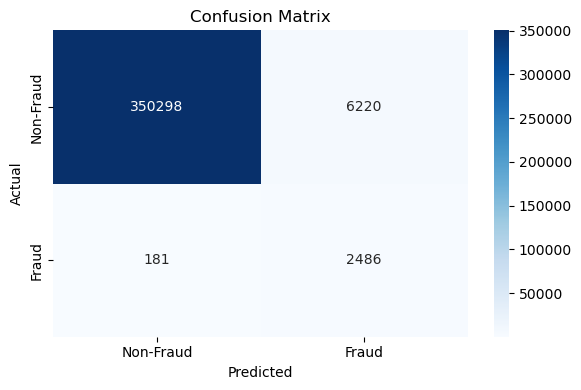

Recall/True Positive Rate: The model got 93.21% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 28.56% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 1.74% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [15]:
y_prob = pipeline.pipeline.predict_proba(X_test)[:, 1]
plot_confusion_matrix(y_test, y_prob, 0.5)

# Calibrated CV

In [18]:
from sklearn.calibration import CalibratedClassifierCV

In [19]:
base_rf = pipeline.get_model()

Returning trained model...


In [20]:
calibrated_rf = CalibratedClassifierCV(
    estimator=base_rf,
    method='sigmoid',
    cv='prefit'
)

In [21]:
calibrated_rf.fit(X_train_ros, y_train_ros)

CalibratedClassifierCV(cv='prefit',
                       estimator=RandomForestClassifier(class_weight='balanced_subsample',
                                                        max_depth=15,
                                                        min_samples_leaf=20,
                                                        n_estimators=1000,
                                                        n_jobs=-1,
                                                        random_state=42))

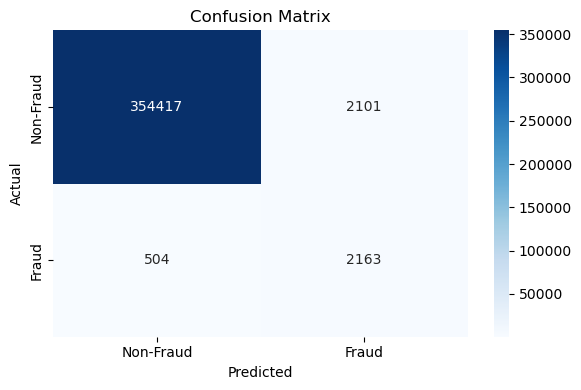

Recall/True Positive Rate: The model got 81.1% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 50.73% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 0.59% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [22]:
y_prob_cal = calibrated_rf.predict_proba(X_test)[:, 1]
plot_confusion_matrix(y_test, y_prob_cal, 0.5)

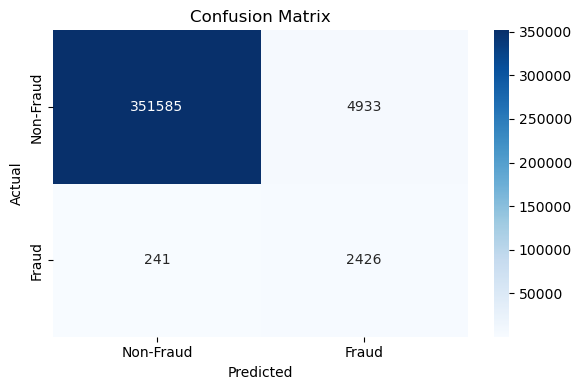

Recall/True Positive Rate: The model got 90.96% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 32.97% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 1.38% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [23]:
plot_confusion_matrix(y_test, y_prob_cal, 0.01)

# Back-Testing with OOS Data

In [17]:
df_credit_mix = pd.read_parquet("data/base/df_credit_clean_dec24_may25.parquet")
trx_id_list = list(df_credit_mix[df_credit_mix.Confirmed.isin([0,1])]['Transaction Serial No'])
df_oos_new = df_splits["df_test"][df_splits["df_test"].index.isin(trx_id_list)]

In [18]:
X_oos, y_oos = pipeline.prepare_data(
    df=df_splits["df_test"],
    # df=df_oos_new,
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_apply_one_hot=False,
    is_apply_log=True,
    is_impute_median=True,
    is_training=False
)

Preparing data (is_training=False)...
Starting core numeric and boolean preprocessing...
  Float columns to downcast: ['time_diff', 'TxnCount_L15M', 'TxnCount_L1H', 'TxnCount_L1D', 'TxnCount_L7D', 'TxnCount_L14D', 'TxnCount_L30D', 'TxnCount_L90D', 'TxnCount_to_MCC_L15M', 'TxnCount_to_MCC_L1H', 'TxnCount_to_MCC_L1D', 'TxnCount_to_MCC_L7D', 'TxnCount_to_MCC_L14D', 'TxnCount_to_MCC_L30D', 'TxnCount_to_MCC_L90D', 'TxnCount_to_MCC_details_L15M', 'TxnCount_to_MCC_details_L1H', 'TxnCount_to_MCC_details_L1D', 'TxnCount_to_MCC_details_L7D', 'TxnCount_to_MCC_details_L14D', 'TxnCount_to_MCC_details_L30D', 'TxnCount_to_MCC_details_L90D', 'TxnCount_to_MCC_catcode_L15M', 'TxnCount_to_MCC_catcode_L1H', 'TxnCount_to_MCC_catcode_L1D', 'TxnCount_to_MCC_catcode_L7D', 'TxnCount_to_MCC_catcode_L14D', 'TxnCount_to_MCC_catcode_L30D', 'TxnCount_to_MCC_catcode_L90D', 'TxnCount_to_MCC_cat_L15M', 'TxnCount_to_MCC_cat_L1H', 'TxnCount_to_MCC_cat_L1D', 'TxnCount_to_MCC_cat_L7D', 'TxnCount_to_MCC_cat_L14D', 'TxnCoun

In [19]:
# Evaluate ALL trx
oos_results = pipeline.evaluate(X_oos, y_oos)

Evaluating model...
Accuracy: 0.9885
AUC: 0.9906
PR AUC: 0.6606
Precision: 0.3651
Recall: 0.7540

Classification Report:
               precision    recall  f1-score   support

       False       1.00      0.99      0.99    200054
        True       0.37      0.75      0.49      1492

    accuracy                           0.99    201546
   macro avg       0.68      0.87      0.74    201546
weighted avg       0.99      0.99      0.99    201546



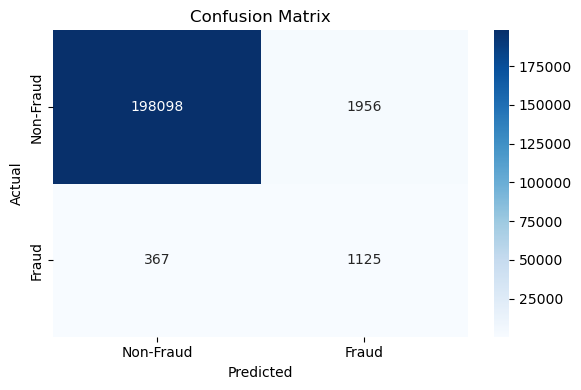

Recall/True Positive Rate: The model got 75.4% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 36.51% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 0.98% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [20]:
y_oos_prob = pipeline.pipeline.predict_proba(X_oos)[:, 1]
plot_confusion_matrix(y_oos, y_oos_prob, 0.5)

## Calibrated Eval

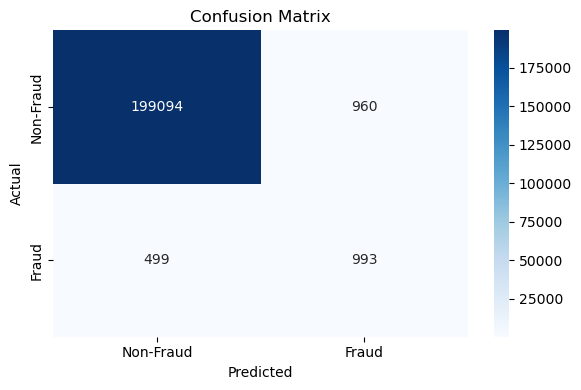

Recall/True Positive Rate: The model got 66.55% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 50.84% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 0.48% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [28]:
y_oos_prob_cal = calibrated_rf.predict_proba(X_oos)[:, 1]
plot_confusion_matrix(y_oos, y_oos_prob_cal, 0.1)

## Threshold Tuning

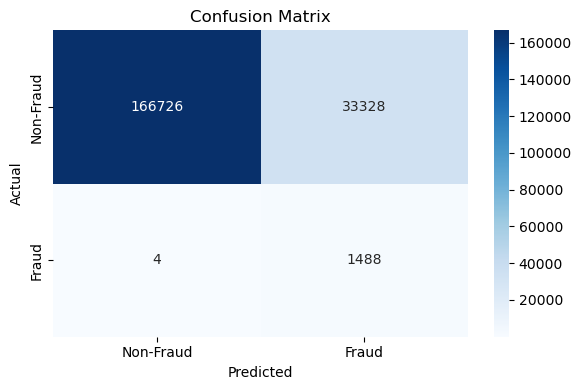

Recall/True Positive Rate: The model got 99.73% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 4.27% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 16.66% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [30]:
plot_confusion_matrix(y_true=y_oos, y_prob=y_oos_prob, threshold=0.02)

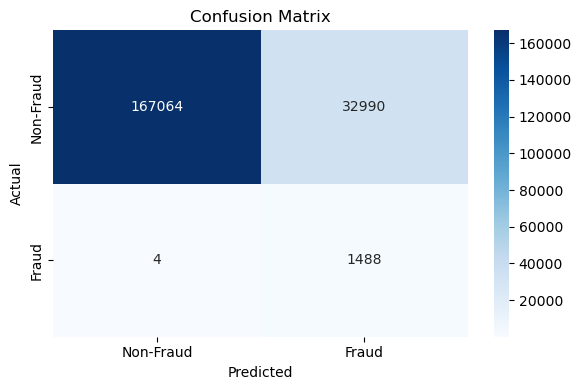

Recall/True Positive Rate: The model got 99.73% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 4.32% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 16.49% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [45]:
plot_confusion_matrix(y_oos, y_oos_prob_cal, 0.00000007)

In [21]:
len(X_oos.columns)

276

In [48]:
import pickle

filepath = "model/credit/base_rf_271_feats_20250619.pkl"
with open(filepath, "wb") as f:
    pickle.dump(base_rf, f)

# Eval ALERT Transactions Only

In [ ]:
# Evaluate ALERT trx only
X_oos_new, y_oos_new = pipeline.prepare_data(
    # df=df_splits["df_test"],
    df=df_oos_new,
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_training=False # set to False for back-testing/predicting OOS data
)

In [ ]:
# Evaluate ALERT trx only
oos_results = pipeline.evaluate(X_oos_new, y_oos_new)

In [ ]:
y_oos_new_prob = pipeline.pipeline.predict_proba(X_oos_new)[:, 1]
plot_confusion_matrix(y_oos_new, y_oos_new_prob, 0.5)

# Feature Importance

In [42]:
# Feature importance
importance_df = pipeline.get_feature_importance(X_train_ros, y_train_ros)

Getting feature importances...
  Using native feature importances.


In [44]:
pd.set_option("display.max_rows", None)
importance_df['importance'] = np.round(importance_df['importance'], 6)
importance_df

,feature,importance
11,time_diff,0.101744
32,MCC Category_BUSINESS/PROFESSIONAL/MISCELLANEO...,0.098616
47,POSMode_1,0.083393
17,Transaction Amount,0.069505
14,TotalTrxAmount30Mi,0.045291
10,TxnCount_to_countryCode_L30D,0.039626
7,Sum_Amt_to_MCC_L30D,0.036443
4,Max_Amt_to_MCC_L30D,0.033320
1,Avg_Amt_to_MCC_L30D,0.032923
13,TotalTrxAmount15Mi,0.032613


# Train High-Precision Model

In [143]:
threshold = 0.5
mask = y_prob_cal < threshold

In [144]:
mask_series = pd.Series(mask, index=X_test.index)
X_candidates = X_test.loc[mask_series]
y_candidates = y_test.loc[mask_series]

In [145]:
X_test.shape, X_candidates.shape

((359185, 72), (350952, 72))

In [146]:
# split data
X_cdd_train, X_cdd_test, y_cdd_train, y_cdd_test = pipeline.split_data(
    X_candidates, y_candidates, test_size=0.2
)

Splitting data into train and test sets...
Data splitting complete.


In [147]:
# OverSampling
ros_sampler = ImbalancedSampler(
    algorithm='RandomOverSampler',
    sampler_type='upsample',
    target_ratio=0.2, # 7%
    random_state=1234
)

X_cdd_train_ros, y_cdd_train_ros = ros_sampler.fit_resample(X_cdd_train, y_cdd_train)

Original dataset shape: Counter({False: 280358, True: 403})
Resampled dataset shape using RandomOverSampler: Counter({False: 280358, True: 56071})


In [148]:
# re-init
pipeline = ModelPipeline(
    model_type="xgboost",
    random_state=42
)
# built and train
pipeline.build_pipeline()
pipeline.train(X_cdd_train_ros, y_cdd_train_ros, show_training_log=False)

Initializing ModelPipeline with model type: xgboost
Retrieving model instance for type: xgboost
Building pipeline...
Pipeline built.
Training model...


C:\Users\Administrator\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:17:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model training complete.


In [149]:
xgb = pipeline.get_model()

Returning trained model...


In [150]:
calibrated_xgb = CalibratedClassifierCV(
    estimator=xgb,
    method='sigmoid',
    cv='prefit'
)
calibrated_xgb.fit(X_cdd_train_ros, y_cdd_train_ros)

CalibratedClassifierCV(cv='prefit',
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=None,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric='logloss',
                                               feature_types=None,
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=None, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None,
                                               max_depth=None, max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=1000, n_jobs=-1,
                                               num_parallel_tree=None, ...))

In [151]:
# Evaluate
cdd_test_results = pipeline.evaluate(X_cdd_test, y_cdd_test)

Evaluating model...
Accuracy: 0.9980
AUC: 0.8419
PR AUC: 0.0868
Precision: 0.2029
Recall: 0.1386

Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00     70090
        True       0.20      0.14      0.16       101

    accuracy                           1.00     70191
   macro avg       0.60      0.57      0.58     70191
weighted avg       1.00      1.00      1.00     70191



## Backtest with OOS Data

In [152]:
threshold_oos = 0.5
mask_oos = y_oos_prob_cal < threshold_oos

In [153]:
mask_oos_series = pd.Series(mask_oos, index=X_oos.index)
X_oos_cdd = X_oos.loc[mask_oos_series]
y_oos_cdd = y_oos.loc[mask_oos_series]

In [154]:
y_oos_cdd_prob = xgb.predict_proba(X_oos_cdd)[:, 1]

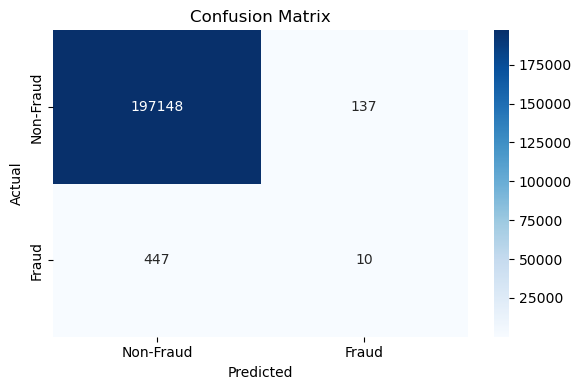

Recall/True Positive Rate: The model got 2.19% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 6.8% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 0.07% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [155]:
plot_confusion_matrix(y_oos_cdd, y_oos_cdd_prob, 0.5)

In [103]:
y_oos_cdd_prob_cal = calibrated_xgb.predict_proba(X_oos_cdd)[:, 1]

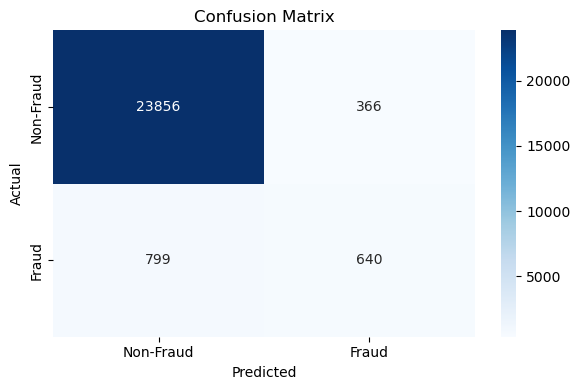

Recall/True Positive Rate: The model got 44.48% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 63.62% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 1.51% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [109]:
plot_confusion_matrix(y_oos_cdd, y_oos_cdd_prob_cal, 0.5)

In [110]:
y_oos_cdd_rf_cal = calibrated_rf.predict_proba(X_oos_cdd)[:, 1]

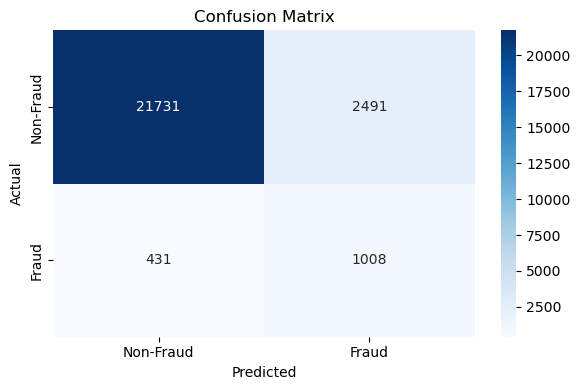

Recall/True Positive Rate: The model got 70.05% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 28.81% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 10.28% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [133]:
plot_confusion_matrix(y_oos_cdd, y_oos_cdd_rf_cal, 0.6)

## Combine Proba

In [114]:
y_oos_rf = calibrated_rf.predict_proba(X_oos)[:, 1]
y_oos_xgb = calibrated_xgb.predict_proba(X_oos)[:, 1]

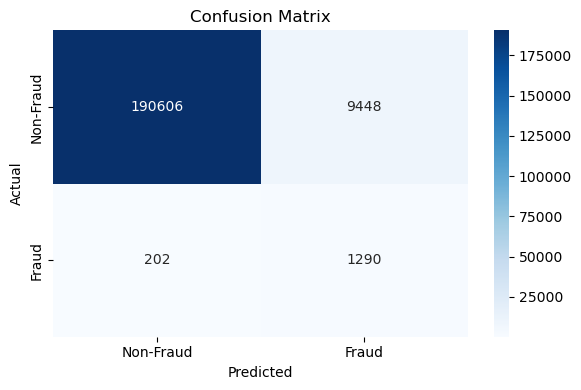

Recall/True Positive Rate: The model got 86.46% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 12.01% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 4.72% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [126]:
rf_prop = 0.1
xgb_prop = 0.9

y_oos_combine = (y_oos_rf * rf_prop) + (y_oos_xgb * xgb_prop)
plot_confusion_matrix(y_oos, y_oos_combine, 0.0015)

## Analysis

In [130]:
df_analysis_post_rf_base = X_oos_cdd.copy()
df_analysis_post_rf_base["Confirmed"] = y_oos_cdd
df_analysis_post_rf_base["RF_cal_proba"] = calibrated_rf.predict_proba(X_oos_cdd)[:, 1]
df_analysis_post_rf_base = df_analysis_post_rf_base[["Confirmed","RF_cal_proba"]]

<Axes: xlabel='RF_cal_proba', ylabel='Density'>

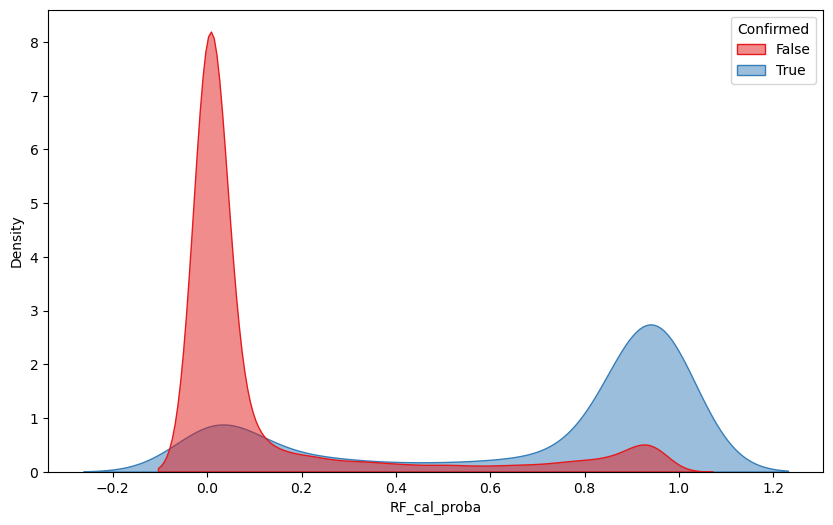

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.kdeplot(
    data=df_analysis_post_rf_base,
    x="RF_cal_proba",
    hue="Confirmed",
    common_norm=False,
    fill=True,
    palette="Set1",
    alpha=0.5
)